<a href="https://colab.research.google.com/github/Mariyamkhair/https-colab.research.google.com-drive-1CZWbKJCYQb85JdTyHSM3HCzNkGPs04DX-/blob/main/Car_Data_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CAR DATA OREDICTION

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv('/content/Car_data_jtrjuw.csv')

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


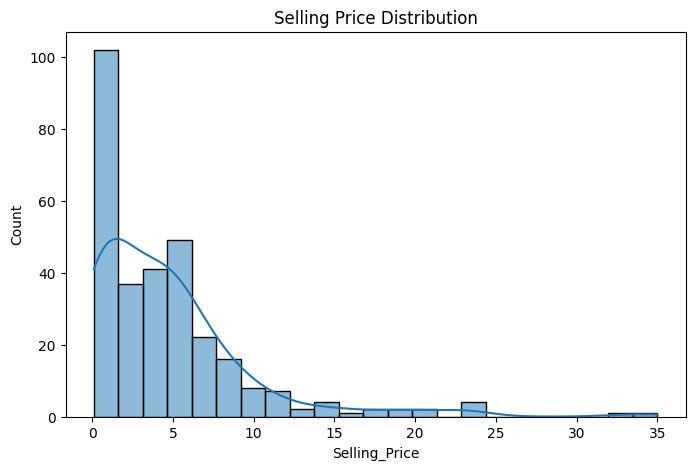

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Selling Price Distribution')
plt.show()

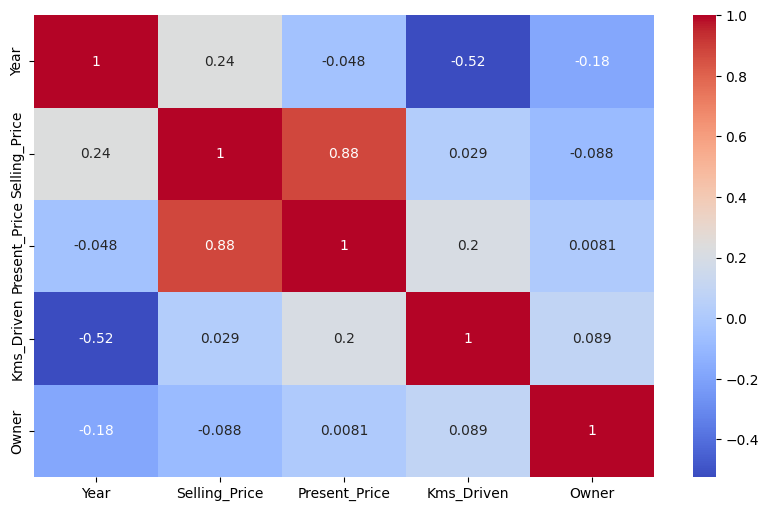

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

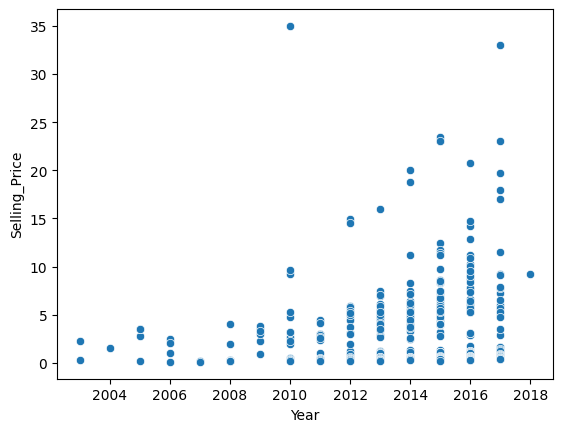

In [12]:
sns.scatterplot(x='Year', y='Selling_Price', data=df)
plt.show()

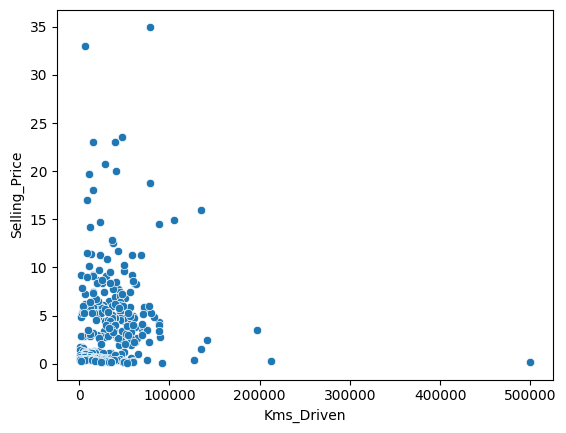

In [14]:
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df)
plt.show()

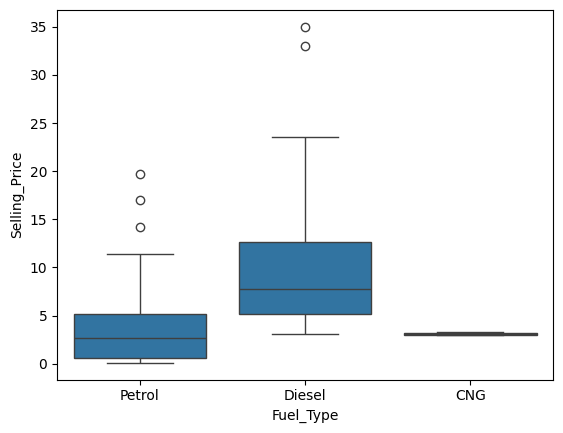

In [16]:
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.show()

In [18]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [19]:
numerical_cols = X.select_dtypes(include=['int64','float64']).columns

categorical_cols = X.select_dtypes(include=['object']).columns

In [23]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [26]:
y_pred = model.predict(X_test)

In [27]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.1021419132144532


In [28]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.1021419132144532


In [30]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)
# Interpretation

R² Score: 0.9007113364668833


In [31]:
sample_cars = X_test.head(5)

predictions = model.predict(sample_cars)

results = sample_cars.copy()
results['Predicted_Price'] = predictions

results

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Predicted_Price
177,Honda Activa 125,2016,0.57,24000,Petrol,Individual,Automatic,0,1.494463
289,city,2016,13.60,10980,Petrol,Dealer,Manual,0,9.593119
228,verna,2012,9.40,60000,Diesel,Dealer,Manual,0,5.505179
198,Bajaj Discover 125,2011,0.57,35000,Petrol,Individual,Manual,1,-0.409634
60,corolla altis,2013,18.61,40001,Petrol,Dealer,Manual,0,8.564933
